In [1]:
import os
import sys
# block warnings from printing
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

import xarray as xr
xr.set_options(keep_attrs=True)
import numpy as np
np.seterr(divide='ignore', invalid='ignore')

import cartopy
cartopy.config['data_dir'] = "/discover/nobackup/projects/jh_tutorials/JH_examples/JH_datafiles/Cartopy"
cartopy.config['pre_existing_data_dir'] = "/discover/nobackup/projects/jh_tutorials/JH_examples/JH_datafiles/Cartopy"
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from shapely.geometry.polygon import LinearRing

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from matplotlib.colors import TwoSlopeNorm
from matplotlib import cm
from matplotlib.colors import ListedColormap,LinearSegmentedColormap
import cmocean.cm as cmo

# settings
%config InlineBackend.figure_format = 'retina'

# add path to custom functions
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path+"/py_functions")
from colorbar_funcs import *
from data_funcs import *
from stats_funcs import *
from domain_funcs import *

dpath0='/discover/nobackup/projects/giss/baldwin_nip/dmkumar'

In [2]:
### +++ DATA PATHS +++ ###

obs_prods     = ['merra2']
flor_runs     = ['ctrl', 'hitopo']

files = {
    'obs':   {'merra2': {}},
    'pi':    {'ctrl': {}, 'hitopo': {}},
    '2xco2': {'ctrl': {}, 'hitopo': {}},
    'topo':  {}
}

files['obs']['merra2']['h500'] = f'{dpath0}/obs_data/merra2/merra2.H.1980-2022.monthly.nc'

for run in flor_runs:
    files['pi'][run]['h500']    = f'{dpath0}/FLOR/{run}/pi/flor.{run}.h500.monthly.nc'
    files['2xco2'][run]['h500'] = f'{dpath0}/FLOR/{run}/2xco2/flor.{run}.2xco2.h500.monthly.nc'

files['topo']['etopo']  = f'{dpath0}/topo_files/obs.etopo5.zsurf.nc'
files['topo']['ctrl']   = f'{dpath0}/topo_files/flor.ctrl.zsurf.nc'
files['topo']['hicam']  = f'{dpath0}/topo_files/flor.cam.zsurf.nc'
files['topo']['hitopo'] = f'{dpath0}/topo_files/flor.hitopo.zsurf.nc'

In [3]:
### +++ LOAD DATA +++ ###

dat = {
    'obs':    {'merra2': {} },
    'pi':     {'ctrl': {}, 'hitopo': {} },
    '2xco2':  {'ctrl': {}, 'hitopo': {} },
}
topo = {}

# --- sub-setting bounds --- #
n_keep_years = -100
n_keep_mons  = n_keep_years * 12

# --- read & subset raw fields --- #
print('Loading data...')

print('-> MERRA-2')
ds = xr.open_dataset(files['obs']['merra2']['h500'])['H'].sel(lev=500, drop=True)
dat['obs']['merra2']['h500']   = lonFlip(ds)
dat['obs']['merra2']['swp500'] = dat['obs']['merra2']['h500'] - dat['obs']['merra2']['h500'].mean(dim='lon')
del ds

print('-> CM2.5-FLOR')
for case in ['pi','2xco2']:
    for run in flor_runs:
        ds = xr.open_dataset(files[case][run]['h500'])['h500'][n_keep_mons:].rename({'grid_xt': 'lon', 'grid_yt': 'lat'})
        dat[case][run]['h500']   = ds
        dat[case][run]['swp500'] = ds - ds.mean(dim='lon')
        del ds

# --- read & subset topography fields --- #
print('\nLoading topography fields...')
# etopo05
ds = xr.open_dataset(files['topo']['etopo'])['ROSE'].rename({'ETOPO05_X': 'lon', 'ETOPO05_Y': 'lat'})
topo['etopo'] = ds.where(ds > 0, np.nan); del ds
# cm2.5-flor
for run in flor_runs:
    topo[run] = xr.open_dataset(files['topo'][run]).ZSURF.rename({'GRID_XT': 'lon', 'GRID_YT': 'lat'})

print('\nDone.')

Loading data...
-> MERRA-2
-> CM2.5-FLOR

Loading topography fields...

Done.


In [4]:
### +++ JAS SEASONAL MEANS +++ ###

varns  = ['h500', 'swp500']

jas_mean = {
    'obs':    {'merra2': {} },
    'pi':     {'ctrl': {}, 'hitopo': {} },
    '2xco2':  {'ctrl': {}, 'hitopo': {} }
}
ann_jas_mean = {
    'obs':    {'merra2': {} },
    'pi':     {'ctrl': {}, 'hitopo': {} },
    '2xco2':  {'ctrl': {}, 'hitopo': {} }
}

print('Calculating weighted JAS means of raw fields...')
for key, runs in [('obs', obs_prods), ('pi', flor_runs), ('2xco2', flor_runs)]:
    for run in runs:
        for varn in varns:
            jas_mean[key][run][varn]     = jas_seasonal_mean(dat[key][run][varn]).load()
            ann_jas_mean[key][run][varn] = jas_yearly_mean(dat[key][run][varn]).load()
print('Done.')

Calculating weighted JAS means of raw fields...
Done.


In [7]:
## +++ COMPARING ALL MODEL RUNS TO OBS. +++ ##

# --- interpolate obs to FLOR grid --- #
jas_mean_regrid     = {'obs_flor': {}}
ann_jas_mean_regrid = {'obs_flor': {}}

lats = dat['pi']['ctrl']['h500'].lat
lons = dat['pi']['ctrl']['h500'].lon

print('Re-gridding obs to model grid...\n')
for varn in varns:
    jas_mean_regrid['obs_flor'][varn]     = jas_mean['obs']['merra2'][varn].interp(lat=lats, lon=lons, method='linear')
    ann_jas_mean_regrid['obs_flor'][varn] = ann_jas_mean['obs']['merra2'][varn].interp(lat=lats, lon=lons, method='linear')

# --- Significance testing of field differences --- #
obs_diff      = {'pi':    {'ctrl': {}, 'hitopo': {} },
                 '2xco2': {'ctrl': {}, 'hitopo': {} } }
obs_diff_mask = {'pi':    {'ctrl': {}, 'hitopo': {} },
                 '2xco2': {'ctrl': {}, 'hitopo': {} } }
obs_ptvals    = {'pi':    {'ctrl': {}, 'hitopo': {} },
                 '2xco2': {'ctrl': {}, 'hitopo': {} } }

print('Significance testing (model - obs)...')
for case in ['pi','2xco2']:
    print(f'-> {case}')
    for run in flor_runs:
        print(f'---> {run}')
        for varn in varns:
            diff_, mask_, pvals_ = sigtest2n(ann_jas_mean[case][run][varn], ann_jas_mean_regrid['obs_flor'][varn],
                                             jas_mean[case][run][varn], jas_mean_regrid['obs_flor'][varn])
            obs_diff[case][run][varn]      = diff_
            obs_diff_mask[case][run][varn] = mask_
            obs_ptvals[case][run][varn]    = pvals_

print('\nDone.')

Re-gridding obs to model grid...

Significance testing (model - obs)...

-> pi
---> ctrl
---> hitopo
-> 2xco2
---> ctrl
---> hitopo

Done.


In [9]:
## +++ TOPO SENSITIVITY (Modified_Topo - CTRL) +++ ##

# --- Significance testing of field differences --- #
model_diff      = { 'pi':    {'hitopo': {} },
                    '2xco2': {'hitopo': {} } }
model_diff_mask = { 'pi':    {'hitopo': {} },
                    '2xco2': {'hitopo': {} } }
model_ptvals    = { 'pi':    {'hitopo': {} },
                    '2xco2': {'hitopo': {} } }

print('Significance testing (modified - ctrl)...')
for case in ['pi','2xco2']:
    print(f'-> {case}')
    for varn in varns:
        diff_, mask_, pvals_ = sigtest2n(ann_jas_mean[case]['hitopo'][varn], ann_jas_mean[case]['ctrl'][varn],
                                         jas_mean[case]['hitopo'][varn], jas_mean[case]['ctrl'][varn])
        model_diff[case]['hitopo'][varn]      = diff_
        model_diff_mask[case]['hitopo'][varn] = mask_
        model_ptvals[case]['hitopo'][varn]    = pvals_

# --- evaluate where model biases are greater than in the ctrl --- #
# delta_bias = (|OBS-HITOPO| - |OBS-CTRL|)
bias_change        = { 'pi': { 'hitopo':{} } }
bias_change_masked = { 'pi': { 'hitopo':{} } }

case = 'pi'
for run in bias_change[case].keys():
    for varn in varns:
        bias_change[case][run][varn]        = np.abs(obs_diff[case][run][varn]) - np.abs(obs_diff[case]['ctrl'][varn])
        bias_change_masked[case][run][varn] = bias_change[case][run][varn].where(model_diff_mask[case][run][varn].notnull())
        
print('\nDone.')

Significance testing (modified - ctrl)...
-> pi
-> 2xco2

Done.


In [12]:
## +++ CO2 SENSITIVITY (2xCO2 - PI) +++ ##

# --- Significance testing of field differences --- #
future_diff      = { 'ctrl':{}, 'hitopo':{} }
future_diff_mask = { 'ctrl':{}, 'hitopo':{} }
future_ptvals    = { 'ctrl':{}, 'hitopo':{} }

print('Significance testing (2xco2 - pi)...')
for run in ['ctrl','hitopo']:
    print(f'-> {run}')
    for varn in varns:
        diff_, mask_, pvals_ = sigtest2n(ann_jas_mean['2xco2'][run][varn], ann_jas_mean['pi'][run][varn],
                                         jas_mean['2xco2'][run][varn], jas_mean['pi'][run][varn])
        future_diff[run][varn]      = diff_
        future_diff_mask[run][varn] = mask_
        future_ptvals[run][varn]    = pvals_
        
print('\nDone.')

Significance testing (2xco2 - pi)...
-> ctrl
-> hitopo

Done.


# FIGURES

## MERRA-2, CTRL, HIgbl h500 climatologies and model biases

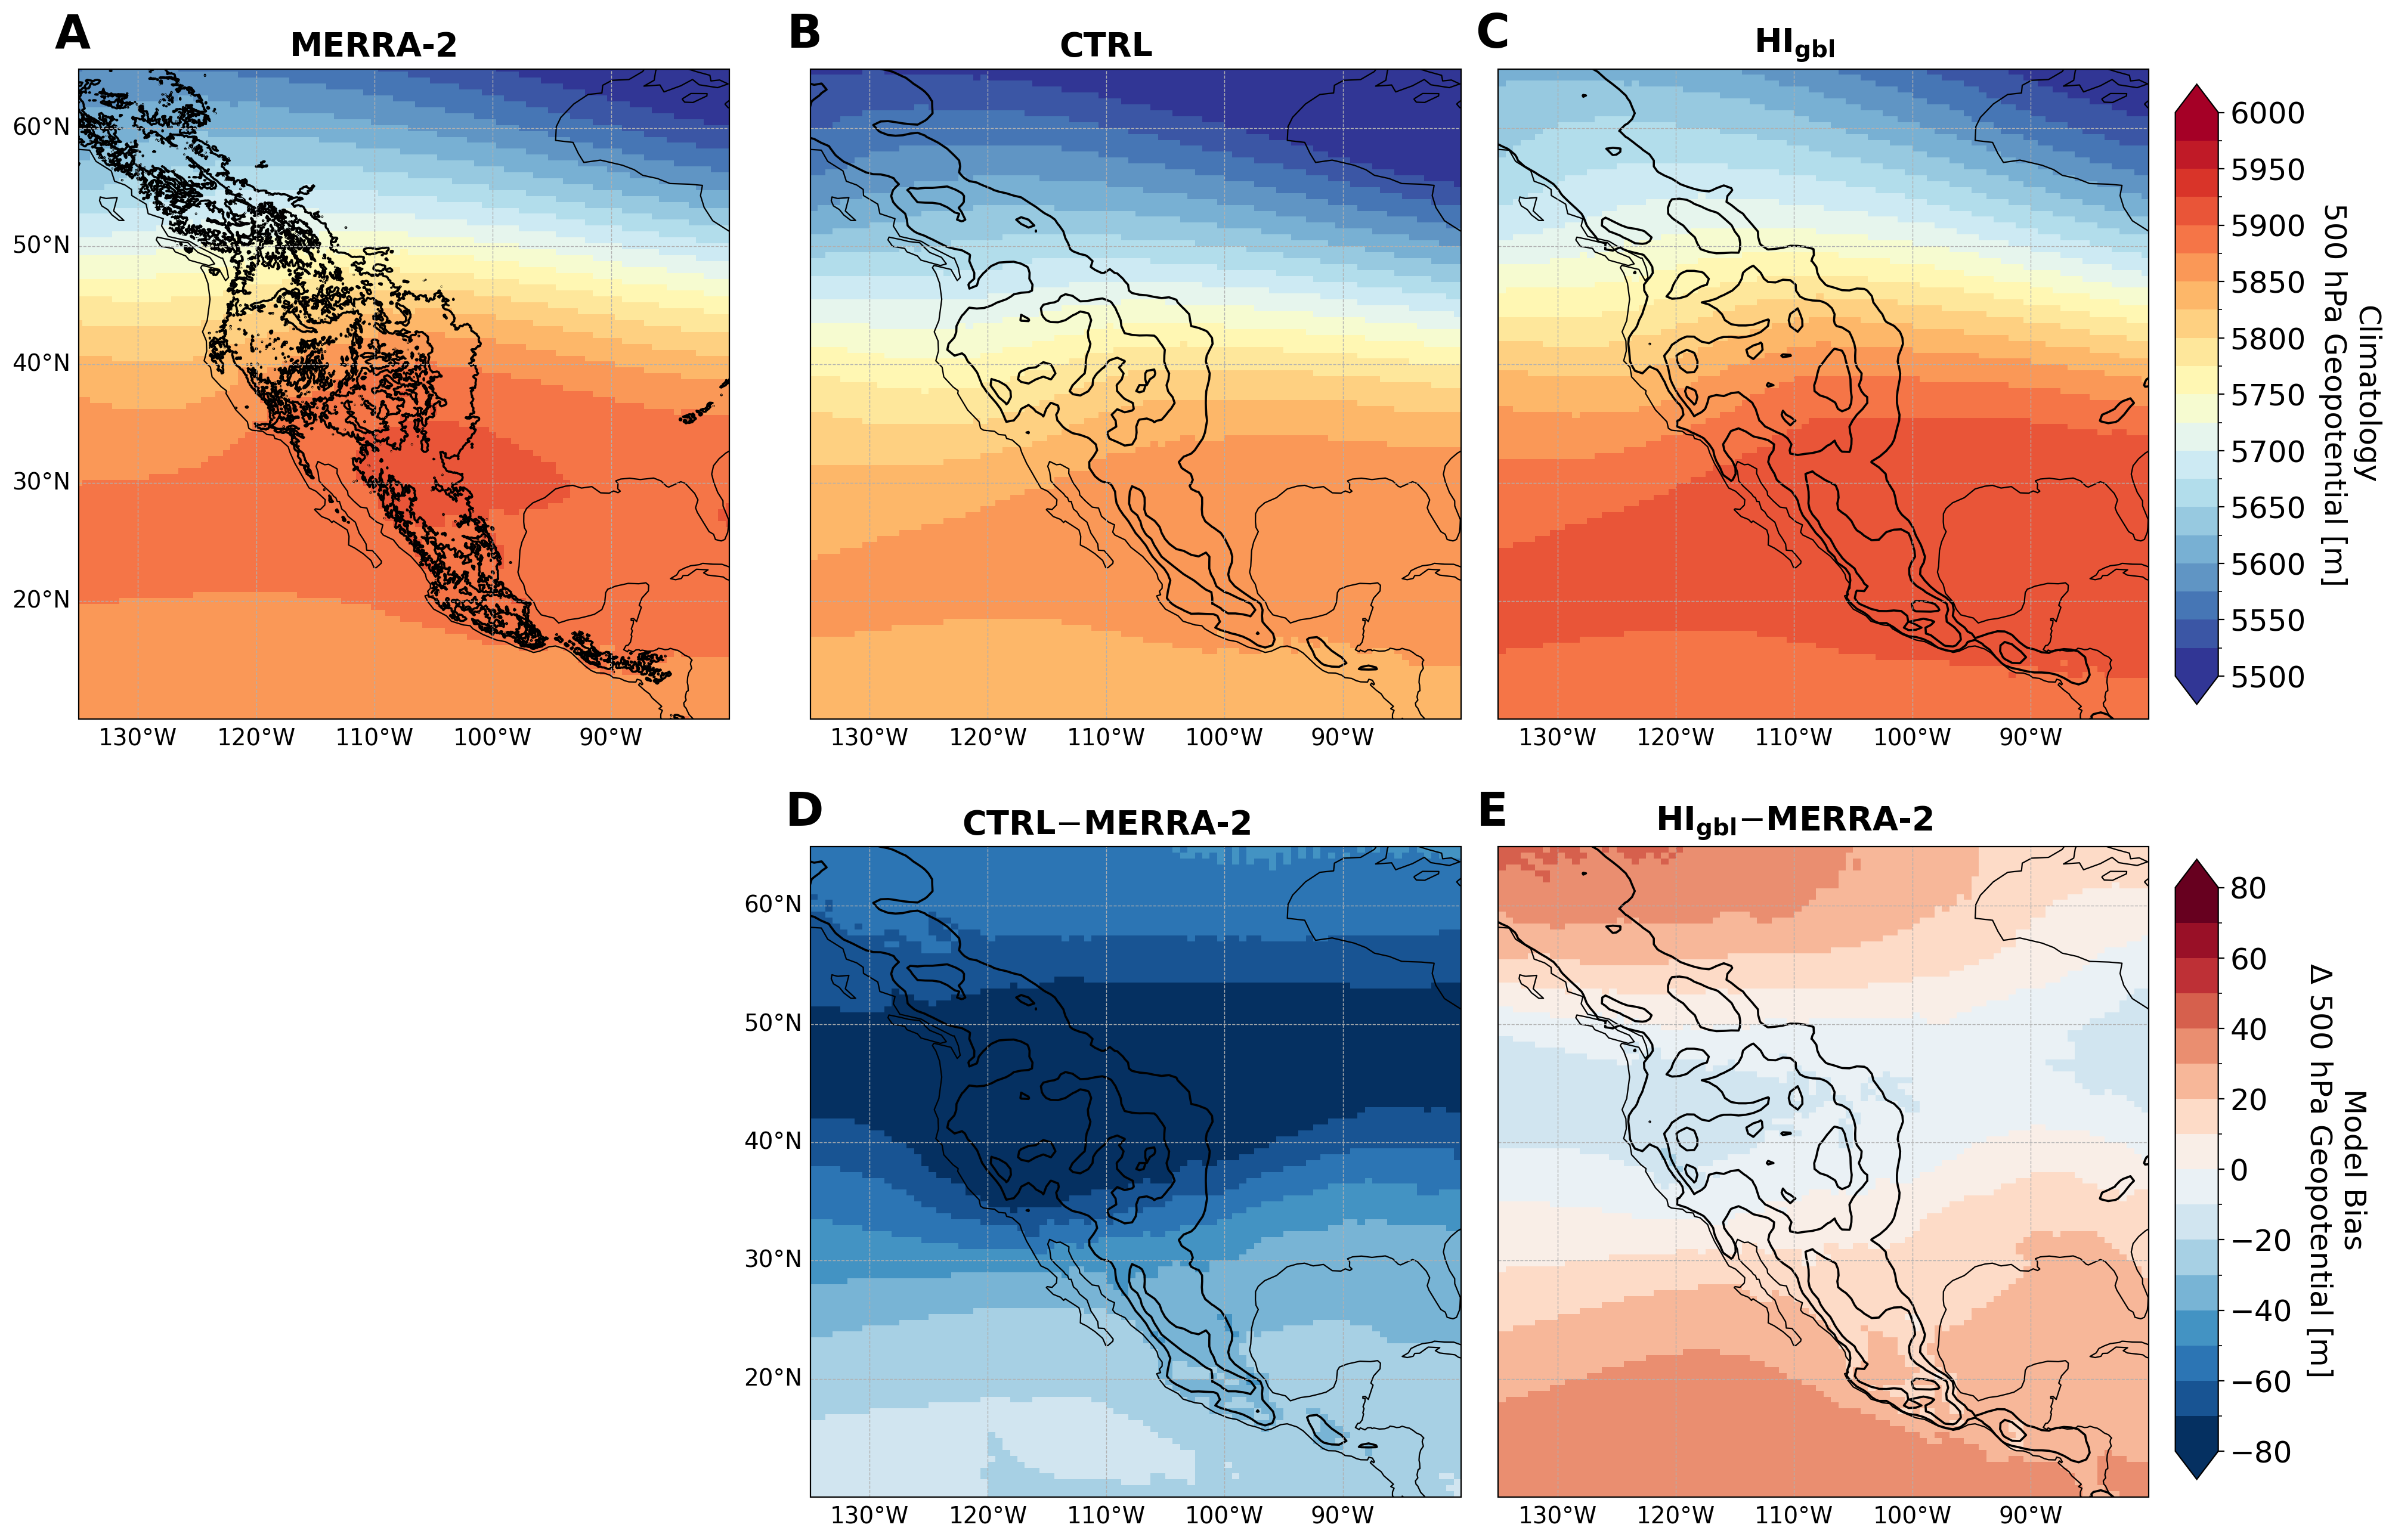

In [20]:
# --- settings --- #
# plot specs
lw=1
text_kw={'color':'k', 'weight':'bold', 'size':20, 'ha':'center', 'va':'bottom'}
text_kw2={'color':'k', 'weight':'bold', 'size':28, 'ha':'center', 'va':'bottom'}
text_kw3={'color':'k', 'weight':'normal', 'size':14, 'ha':'left', 'va':'center'}
titles=np.array(['MERRA-2','CTRL',r'HI$\mathbf{_{gbl}}$',
                 '','CTRL$-$MERRA-2', r'HI$\mathbf{_{gbl}}$$-$MERRA-2'])
letters=['A','B','C','D','D','E','F']
tx=-110
ty=65.5
# topography contours
zlevels=np.linspace(1000,4000,4)
# climo colormap
cmap=cm.RdYlBu_r
vmin=5500
vmax=6000
levels=np.linspace(vmin, vmax, 21)
norm=mpl.colors.BoundaryNorm(levels, cmap.N)
hlevels=np.arange(vmin-50, vmax+50, 25)
# bias colormap
dcmap=cm.RdBu_r
dvmin=-80
dvmax=80
dlevels=np.linspace(dvmin, dvmax, 17)
dnorm=mpl.colors.BoundaryNorm(dlevels, dcmap.N)
# map specs
trans=ccrs.PlateCarree()
proj=ccrs.PlateCarree()
map_bnds=[225,280,10,65]
cols=[0,2]

# --- plot --- #
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(18,13), layout='constrained', subplot_kw={'projection':proj})
ax[1,0].set_visible(False)

# h500 climo
i=0
for key, runs in [('obs', obs_prods), ('pi', flor_runs)]:
    for run in runs:
        h500 = jas_mean[key][run]['h500']
        if key=='pi':
            topo_ = topo[run]
        else:
            topo_ = topo['etopo']
        cf=ax[0,i].pcolormesh(h500.lon, h500.lat, h500, cmap=cmap, norm=norm, transform=trans)
        ax[0,i].contour(topo_.lon, topo_.lat, topo_, levels=zlevels, linewidths=1.3, colors='black', transform=trans)
        i+=1

# h500 biases
for i,run in enumerate(jas_mean['pi'].keys()):
    dh500 = obs_diff['pi'][run]['h500']
    topo_ = topo[run]
    cf2=ax[1,i+1].pcolormesh(dh500.lon, dh500.lat, dh500, cmap=dcmap, norm=dnorm, transform=trans)
    ax[1,i+1].contour(topo_.lon, topo_.lat, topo_, levels=zlevels, linewidths=1.3, colors='black', transform=trans)

# --- formatting --- #
for i, ax in enumerate(ax.flat): 
    # subplot labels
    ax.text(-135.5, ty+.5, letters[i], **text_kw2)
    ax.text(tx, ty, titles[i], **text_kw)
    # map properties
    ax.coastlines(color='k', linewidth=0.8)
    ax.set_extent(map_bnds, crs=trans)
    gl=ax.gridlines(crs=trans, lw=.5, colors='black', alpha=1.0, linestyle='--', zorder=10, draw_labels=True)
    gl.bottom_labels=True; gl.left_labels=(i in {0,3,4}); gl.top_labels=False; gl.right_labels=False
    gl.xformatter=LONGITUDE_FORMATTER
    gl.yformatter=LATITUDE_FORMATTER
    gl.xlabel_style={'color': 'black', 'weight': 'normal', 'size':14}
    gl.ylabel_style={'color': 'black', 'weight': 'normal', 'size':14}

# --- colorbars --- #
# climo
cax=fig.add_axes([1.01, .55, 0.02, 0.4])
cbar=fig.colorbar(cf, ticks=np.linspace(5500,6000,11), orientation='vertical', extend='both', cax=cax) 
cbar.set_label('Climatology\n500 hPa Geopotential [m]', size=18, ha='center', rotation=270, labelpad=45)
cbar.ax.tick_params(labelsize=18)
# bias
cax=fig.add_axes([1.01, .05, 0.02, 0.4])
cbar=fig.colorbar(cf2, ticks=np.linspace(-80,80,9), orientation='vertical', extend='both', cax=cax) 
cbar.set_label('Model Bias\n$\Delta$ 500 hPa Geopotential [m]', size=18, ha='center', rotation=270, labelpad=45)
cbar.ax.tick_params(labelsize=18)

# --- output --- #
plt.savefig('../figs/h500_swp_flor_pi_climo_merra2-bias.pdf', transparent=False, bbox_inches='tight')
plt.savefig('../figs/h500_swp_flor_pi_climo_merra2-bias.png', transparent=False, bbox_inches='tight')

## MERRA-2, CTRL, HIgbl h500 and stationary wave pattern climatologies and HIgbl-CTRL change

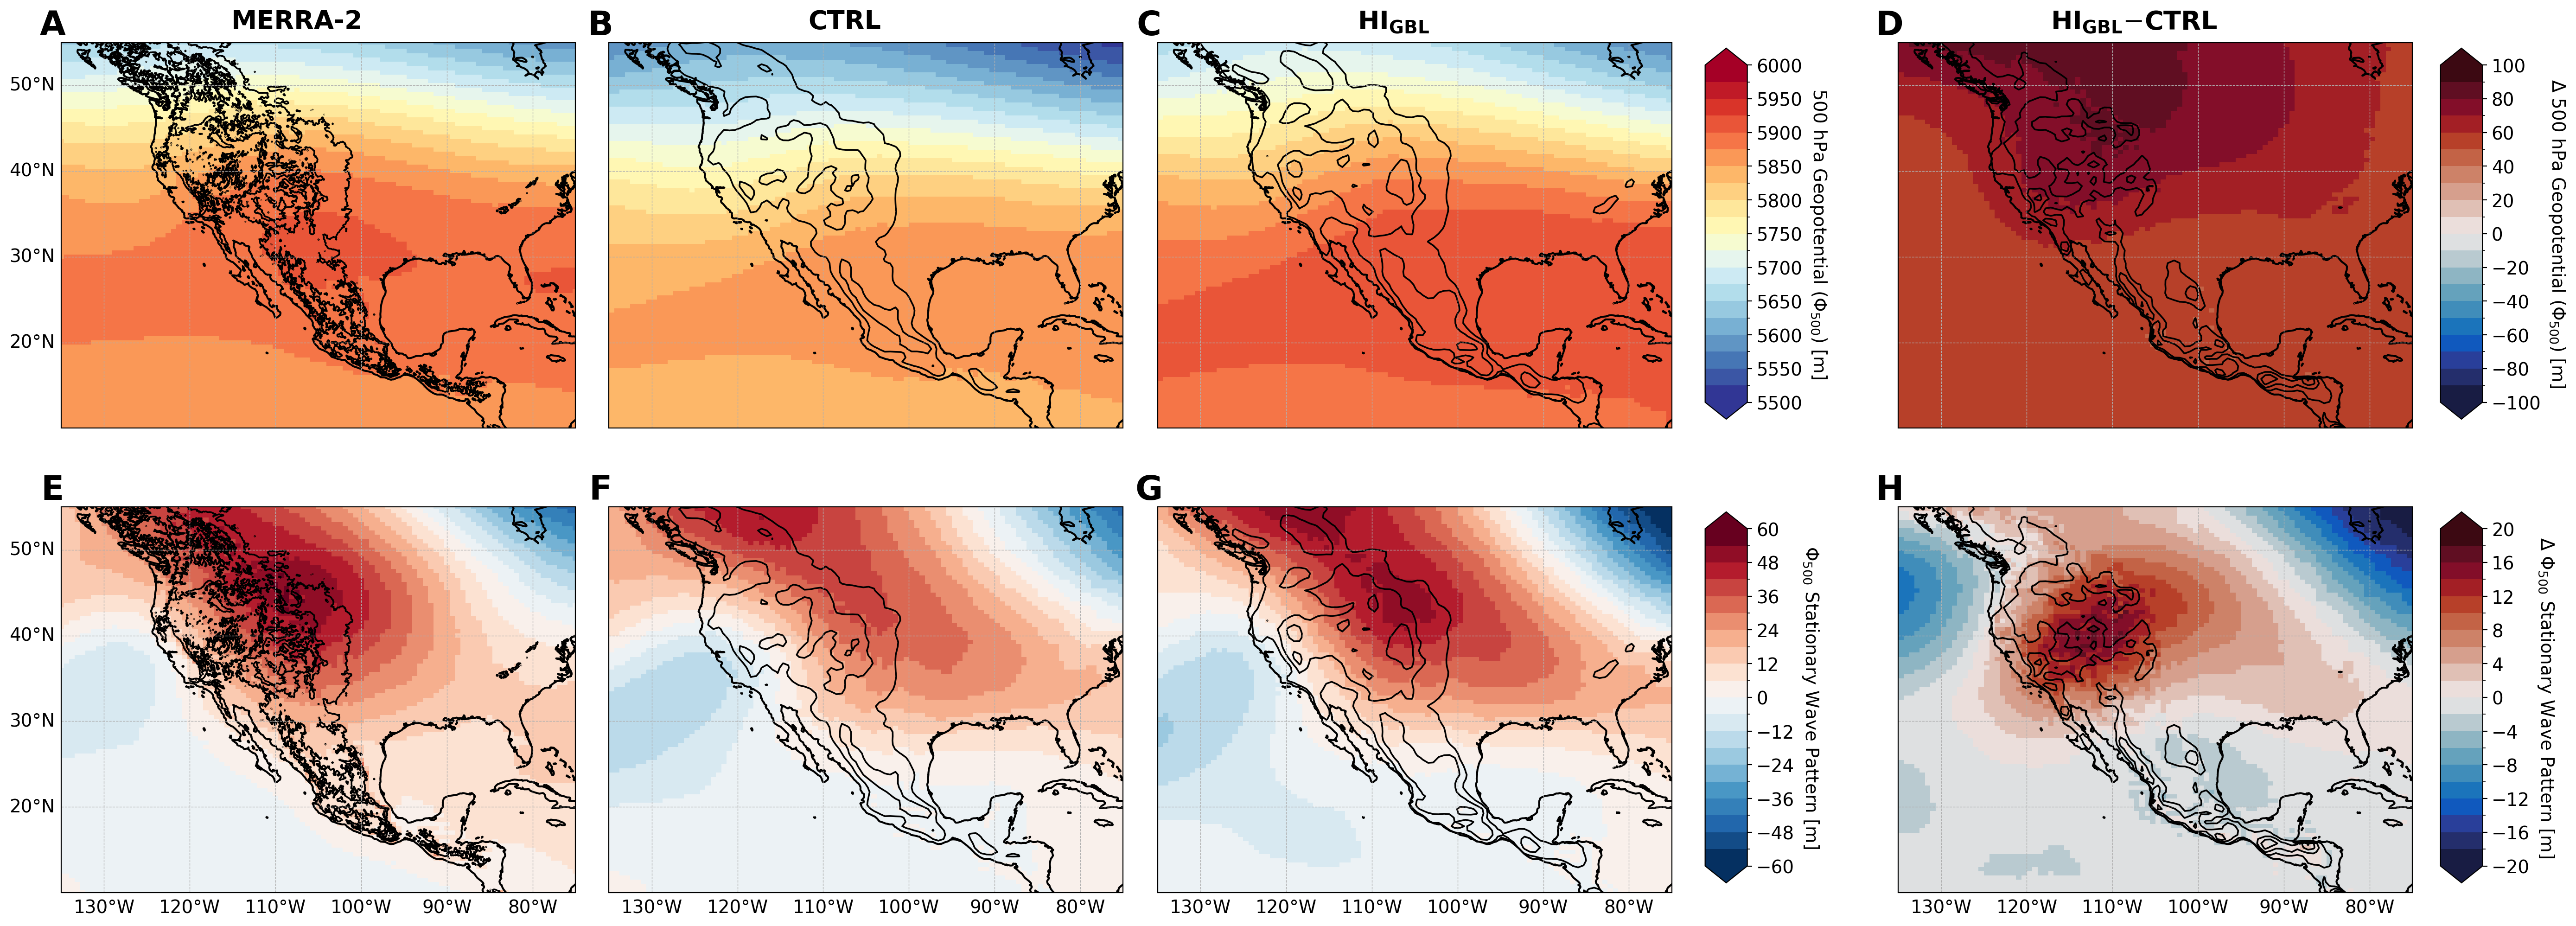

In [21]:
# --- settings --- #
# plot specs
lw=1
text_kw={'color':'k', 'weight':'bold', 'size':20, 'ha':'center', 'va':'bottom'}
text_kw2={'color':'k', 'weight':'bold', 'size':26, 'ha':'center', 'va':'center'}
text_kw3={'color':'k', 'weight':'normal', 'size':14, 'ha':'left', 'va':'center'}
titles=np.array(['MERRA-2','CTRL',r'HI$\mathbf{_{GBL}}$',
                 '','',''])
letters=['A','B','C','D','E','F','G','H']
tx=-107.5
ty=56
# var specs
lon = jas_mean['pi']['ctrl']['h500'].lon
lat = jas_mean['pi']['ctrl']['h500'].lat
# topography contours
zlevels=np.linspace(1000,4000,4)
dzlevels=np.linspace(500,1500,5)
# h500 colormap
cmap=cm.RdYlBu_r
vmin=5500
vmax=6000
levels=np.linspace(vmin, vmax, 21)
norm=mpl.colors.BoundaryNorm(levels, cmap.N)
hlevels=np.arange(vmin-50, vmax+50, 25)
# swp500 colormap
dcmap=cm.RdBu_r
dvmin=-60
dvmax=60
dlevels=np.linspace(dvmin, dvmax, 21)
dnorm=mpl.colors.BoundaryNorm(dlevels, dcmap.N)
# diff colormap
dcmap2=cmo.balance
# map specs
trans=ccrs.PlateCarree()
proj=ccrs.PlateCarree()
map_bnds=[225,285,10,55]
cols=[0,2]

# --- plot --- #
fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(26,10), layout='constrained', subplot_kw={'projection':proj})

for i,title in enumerate(['MERRA-2', 'CTRL', r'HI$\mathbf{_{gbl}}$', r'HI$\mathbf{_{gbl}}$$-$CTRL']):
    ax[0,i].text(tx, ty, title, **text_kw)
    
# climatologies
i=0
for key, runs in [('obs', obs_prods), ('pi', flor_runs)]:
    for run in runs:
        h500 = jas_mean[key][run]['h500']
        swp  = jas_mean[key][run]['swp500']
        if key=='pi':
            topo_ = topo[run]
        else:
            topo_ = topo['etopo']
        cf=ax[0,i].pcolormesh(h500.lon, h500.lat, h500, cmap=cmap, norm=norm, transform=trans)
        cf2=ax[1,i].pcolormesh(swp.lon, swp.lat, swp, cmap=dcmap, norm=dnorm, transform=trans)
        ax[0,i].contour(topo_.lon, topo_.lat, topo_, levels=zlevels, linewidths=1.3, colors='black', transform=trans)
        ax[1,i].contour(topo_.lon, topo_.lat, topo_, levels=zlevels, linewidths=1.3, colors='black', transform=trans)
        i+=1

# cm2.5-flor change
ax[0,3].text(-160,40,' ')
for i,varn in enumerate(['h500','swp500']):
    varn_diff = jas_mean['pi']['hitopo'][varn] - jas_mean['pi']['ctrl'][varn]
    topo_diff = topo['hitopo'] - topo['ctrl']
    if varn=='h500':
        cf3=ax[0,3].pcolormesh(varn_diff.lon, varn_diff.lat, varn_diff, cmap=dcmap2, norm=mpl.colors.BoundaryNorm(np.linspace(-100, 100, 21), dcmap2.N), transform=trans)
    else:
        cf4=ax[1,3].pcolormesh(varn_diff.lon, varn_diff.lat, varn_diff, cmap=dcmap2, norm=mpl.colors.BoundaryNorm(np.linspace(-20, 20, 21), dcmap2.N), transform=trans)
    ax[i,3].contour(topo_diff.lon, topo_diff.lat, topo_diff, levels=dzlevels, linewidths=1.3, colors='black', transform=trans)

# --- formatting --- #
for i, ax in enumerate(ax.flat): 
    # subplot labels
    ax.text(-136, ty+1, letters[i], **text_kw2)
    # map properties
    ax.coastlines(color='k', linewidth=1.5)
    ax.set_extent(map_bnds, crs=trans)
    gl=ax.gridlines(crs=trans, lw=.5, colors='black', alpha=1.0, linestyle='--', zorder=10, draw_labels=True)
    gl.bottom_labels=(i in {4,5,6,7}); gl.left_labels=(i in {0,4}); gl.top_labels=False; gl.right_labels=False
    gl.xformatter=LONGITUDE_FORMATTER
    gl.yformatter=LATITUDE_FORMATTER
    gl.xlabel_style={'color': 'black', 'weight': 'normal', 'size':14}
    gl.ylabel_style={'color': 'black', 'weight': 'normal', 'size':14}

# --- colorbars --- #
# h500
cax=fig.add_axes([.705, .55, 0.0175, 0.4])
cbar=fig.colorbar(cf, ticks=np.linspace(5500,6000,11), orientation='vertical', extend='both', cax=cax) 
cbar.set_label('500 hPa Geopotential ($\Phi_{500}$) [m]', size=14, rotation=270, labelpad=20, ha='center')
cbar.ax.tick_params(labelsize=14)
# swp500
cax=fig.add_axes([.705, .05, 0.0175, 0.4])
cbar=fig.colorbar(cf2, ticks=np.linspace(-60,60,11), orientation='vertical', extend='both', cax=cax) 
cbar.set_label('$\Phi_{500}$ Stationary Wave Pattern [m]', size=14, rotation=270, labelpad=20, ha='center')
cbar.ax.tick_params(labelsize=14)
# h500 change
cax=fig.add_axes([1.01, .55, 0.0174, 0.4])
cbar=fig.colorbar(cf3, ticks=np.linspace(-100,100,11), orientation='vertical', extend='both', cax=cax) 
cbar.set_label('$\Delta$ 500 hPa Geopotential ($\Phi_{500}$) [m]', size=14, rotation=270, labelpad=20, ha='center')
cbar.ax.tick_params(labelsize=14)
# swp500 change
cax=fig.add_axes([1.01, .05, 0.0175, 0.4])                                 
cbar=fig.colorbar(cf4, ticks=np.linspace(-20,20,11), orientation='vertical', extend='both', cax=cax) 
cbar.set_label('$\Delta$ $\Phi_{500}$ Stationary Wave Pattern [m]', size=14, rotation=270, labelpad=20, ha='center')
cbar.ax.tick_params(labelsize=14)

# --- output --- #
#plt.savefig('../figs/h500_swp_flor_pi_climo_change.pdf', transparent=False, bbox_inches='tight')
#plt.savefig('../figs/h500_swp_flor_pi_climo_change.png', transparent=False, bbox_inches='tight')

## CTRL and HIgbl model h500 model biases (vs. MERRA-2) and HIgbl-CTRL change (Preindustrial only)

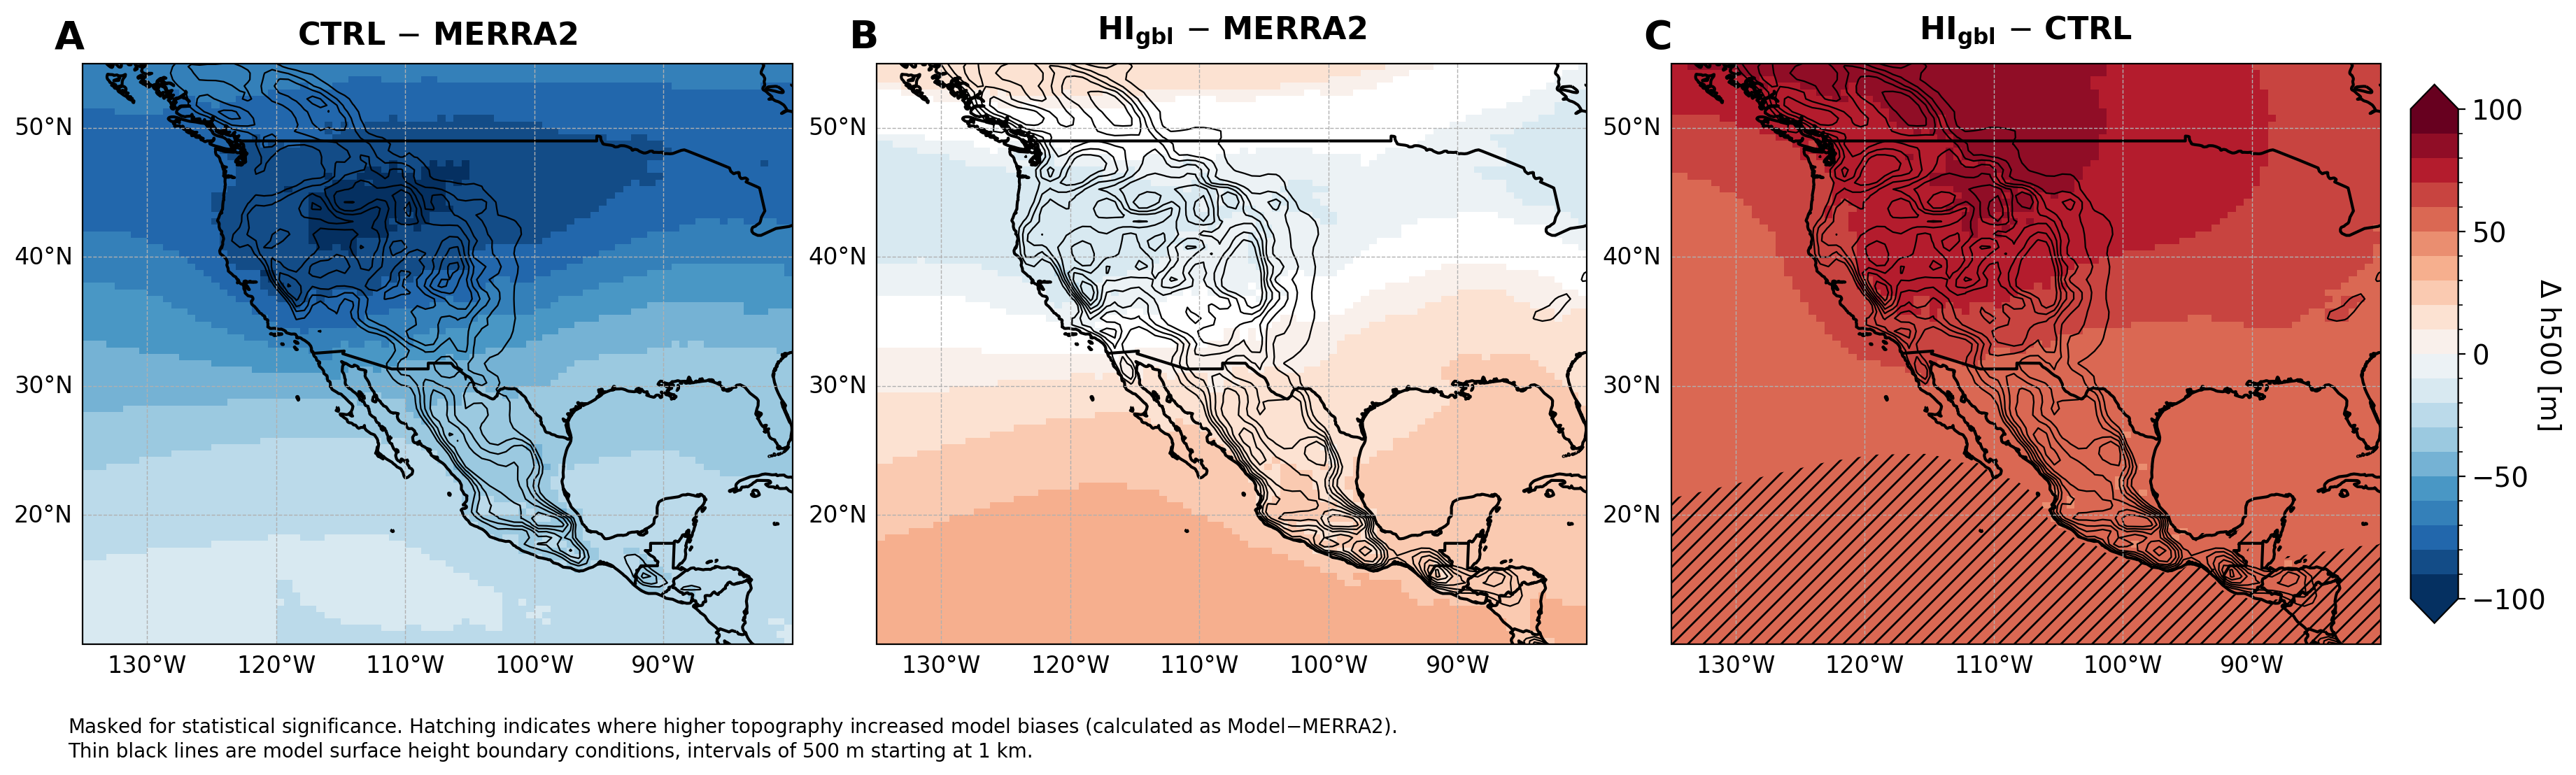

In [11]:
# --- settings --- #
# plot specs
lw=1
text_kw={'color':'k', 'weight':'bold', 'size':16, 'ha':'center', 'va':'bottom'}
text_kw2={'color':'k', 'weight':'bold', 'size':20, 'ha':'center', 'va':'center'}
text_kw3={'color':'k', 'weight':'normal', 'size':10, 'ha':'left', 'va':'center'}
titles=np.array(['CTRL $-$ MERRA2', r'HI$\mathbf{_{gbl}}$ $-$ MERRA2', r'HI$\mathbf{_{gbl}}$ $-$ CTRL'])
letters=['A','B','C','D']
tx=-107.5
ty=56
# var specs
lon = jas_mean['pi']['ctrl']['h500'].lon
lat = jas_mean['pi']['ctrl']['h500'].lat
# topography contours
zlevels=np.linspace(800,3800,7)
# climo colormap
cmap=cm.RdYlBu_r
vmin=5500
vmax=6000
levels=np.linspace(vmin, vmax, 21)
norm=mpl.colors.BoundaryNorm(levels, cmap.N)
hlevels=np.arange(vmin-50, vmax+50, 25)
# bias colormap
dcmap=cm.RdBu_r
dvmin=-100
dvmax=100
dlevels=np.linspace(dvmin, dvmax, 21)
dnorm=mpl.colors.BoundaryNorm(dlevels, dcmap.N)
# map specs
trans=ccrs.PlateCarree()
proj=ccrs.PlateCarree()
map_bnds=[225,280,10,55]
cols=[0,2]


# --- plot --- #
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(17,5.5), layout='constrained', subplot_kw={'projection':proj})

#fig.text(.5,1.0,f'Modified Topo $-$ CTRL', **text_kw)
fig.text(0.025,0,
         'Masked for statistical significance. Hatching indicates where higher topography increased model biases (calculated as Model$-$MERRA2).\n'
         'Thin black lines are model surface height boundary conditions, intervals of 500 m starting at 800 m.',
         **text_kw3)

#=== CTRL ===
for i,run in enumerate(['ctrl','hitopo']):
    cf=ax[i].pcolormesh(lon, lat, obs_diff_mask['pi'][run]['h500'], cmap=dcmap, norm=dnorm, transform=trans)
    ax[i].contour(lon, lat, topo[run], levels=zlevels, linewidths=.8, colors='black', transform=trans)

#=== HI-GBL ===
ax[2].pcolormesh(lon, lat, model_diff_mask['pi']['hitopo']['h500'], cmap=dcmap, norm=dnorm, transform=trans)
ax[2].contour(lon, lat, topo['hitopo'], levels=zlevels, linewidths=.8, colors='black', transform=trans)
# add hatching where bias got worse
ax[2].contourf(lon, lat, bias_change_masked['pi']['hitopo']['h500'],
               0, colors='none', hatches=['','///'], extend='lower', zorder=100, transform=trans)

# --- formatting --- #
for i, ax in enumerate(ax.flat): 
    # subplot labels
    ax.text(tx, ty, titles[i], **text_kw)
    ax.text(-136, ty+1, letters[i], **text_kw2)
    # map properties
    ax.coastlines(color='k', linewidth=1.5)
    ax.add_feature(cfeature.BORDERS, edgecolor='k', linewidth=1.5)
    ax.set_extent(map_bnds, crs=trans)
    gl=ax.gridlines(crs=trans, lw=.5, colors='black', alpha=1.0, linestyle='--', zorder=10, draw_labels=True)
    gl.bottom_labels=True; gl.left_labels=True; gl.top_labels=False; gl.right_labels=False
    gl.xformatter=LONGITUDE_FORMATTER
    gl.yformatter=LATITUDE_FORMATTER
    gl.xlabel_style={'color': 'black', 'weight': 'normal', 'size':12}
    gl.ylabel_style={'color': 'black', 'weight': 'normal', 'size':12}

# --- colorbar --- #
cax=fig.add_axes([1.01, 0.15, 0.02, 0.7])
cbar=fig.colorbar(cf, ticks=np.linspace(-100,100,5), orientation='vertical', extend='both', cax=cax)
cbar.set_label('$\Delta$ h500 [m]', labelpad=8, rotation=270, size=14, fontweight='normal', ha='center')
cbar.ax.tick_params(labelsize=14)
for tick in cbar.ax.yaxis.get_major_ticks():
    tick.label2.set_fontweight('normal')

#plt.savefig(f'{opath}/slp.flor.e3.nam-change.{season}.pdf', transparent=False, bbox_inches='tight')

## CTRL, HIgbl h500 climatologies and model biases (vs. MERRA-2) (Preindustrial and 2xCO2)

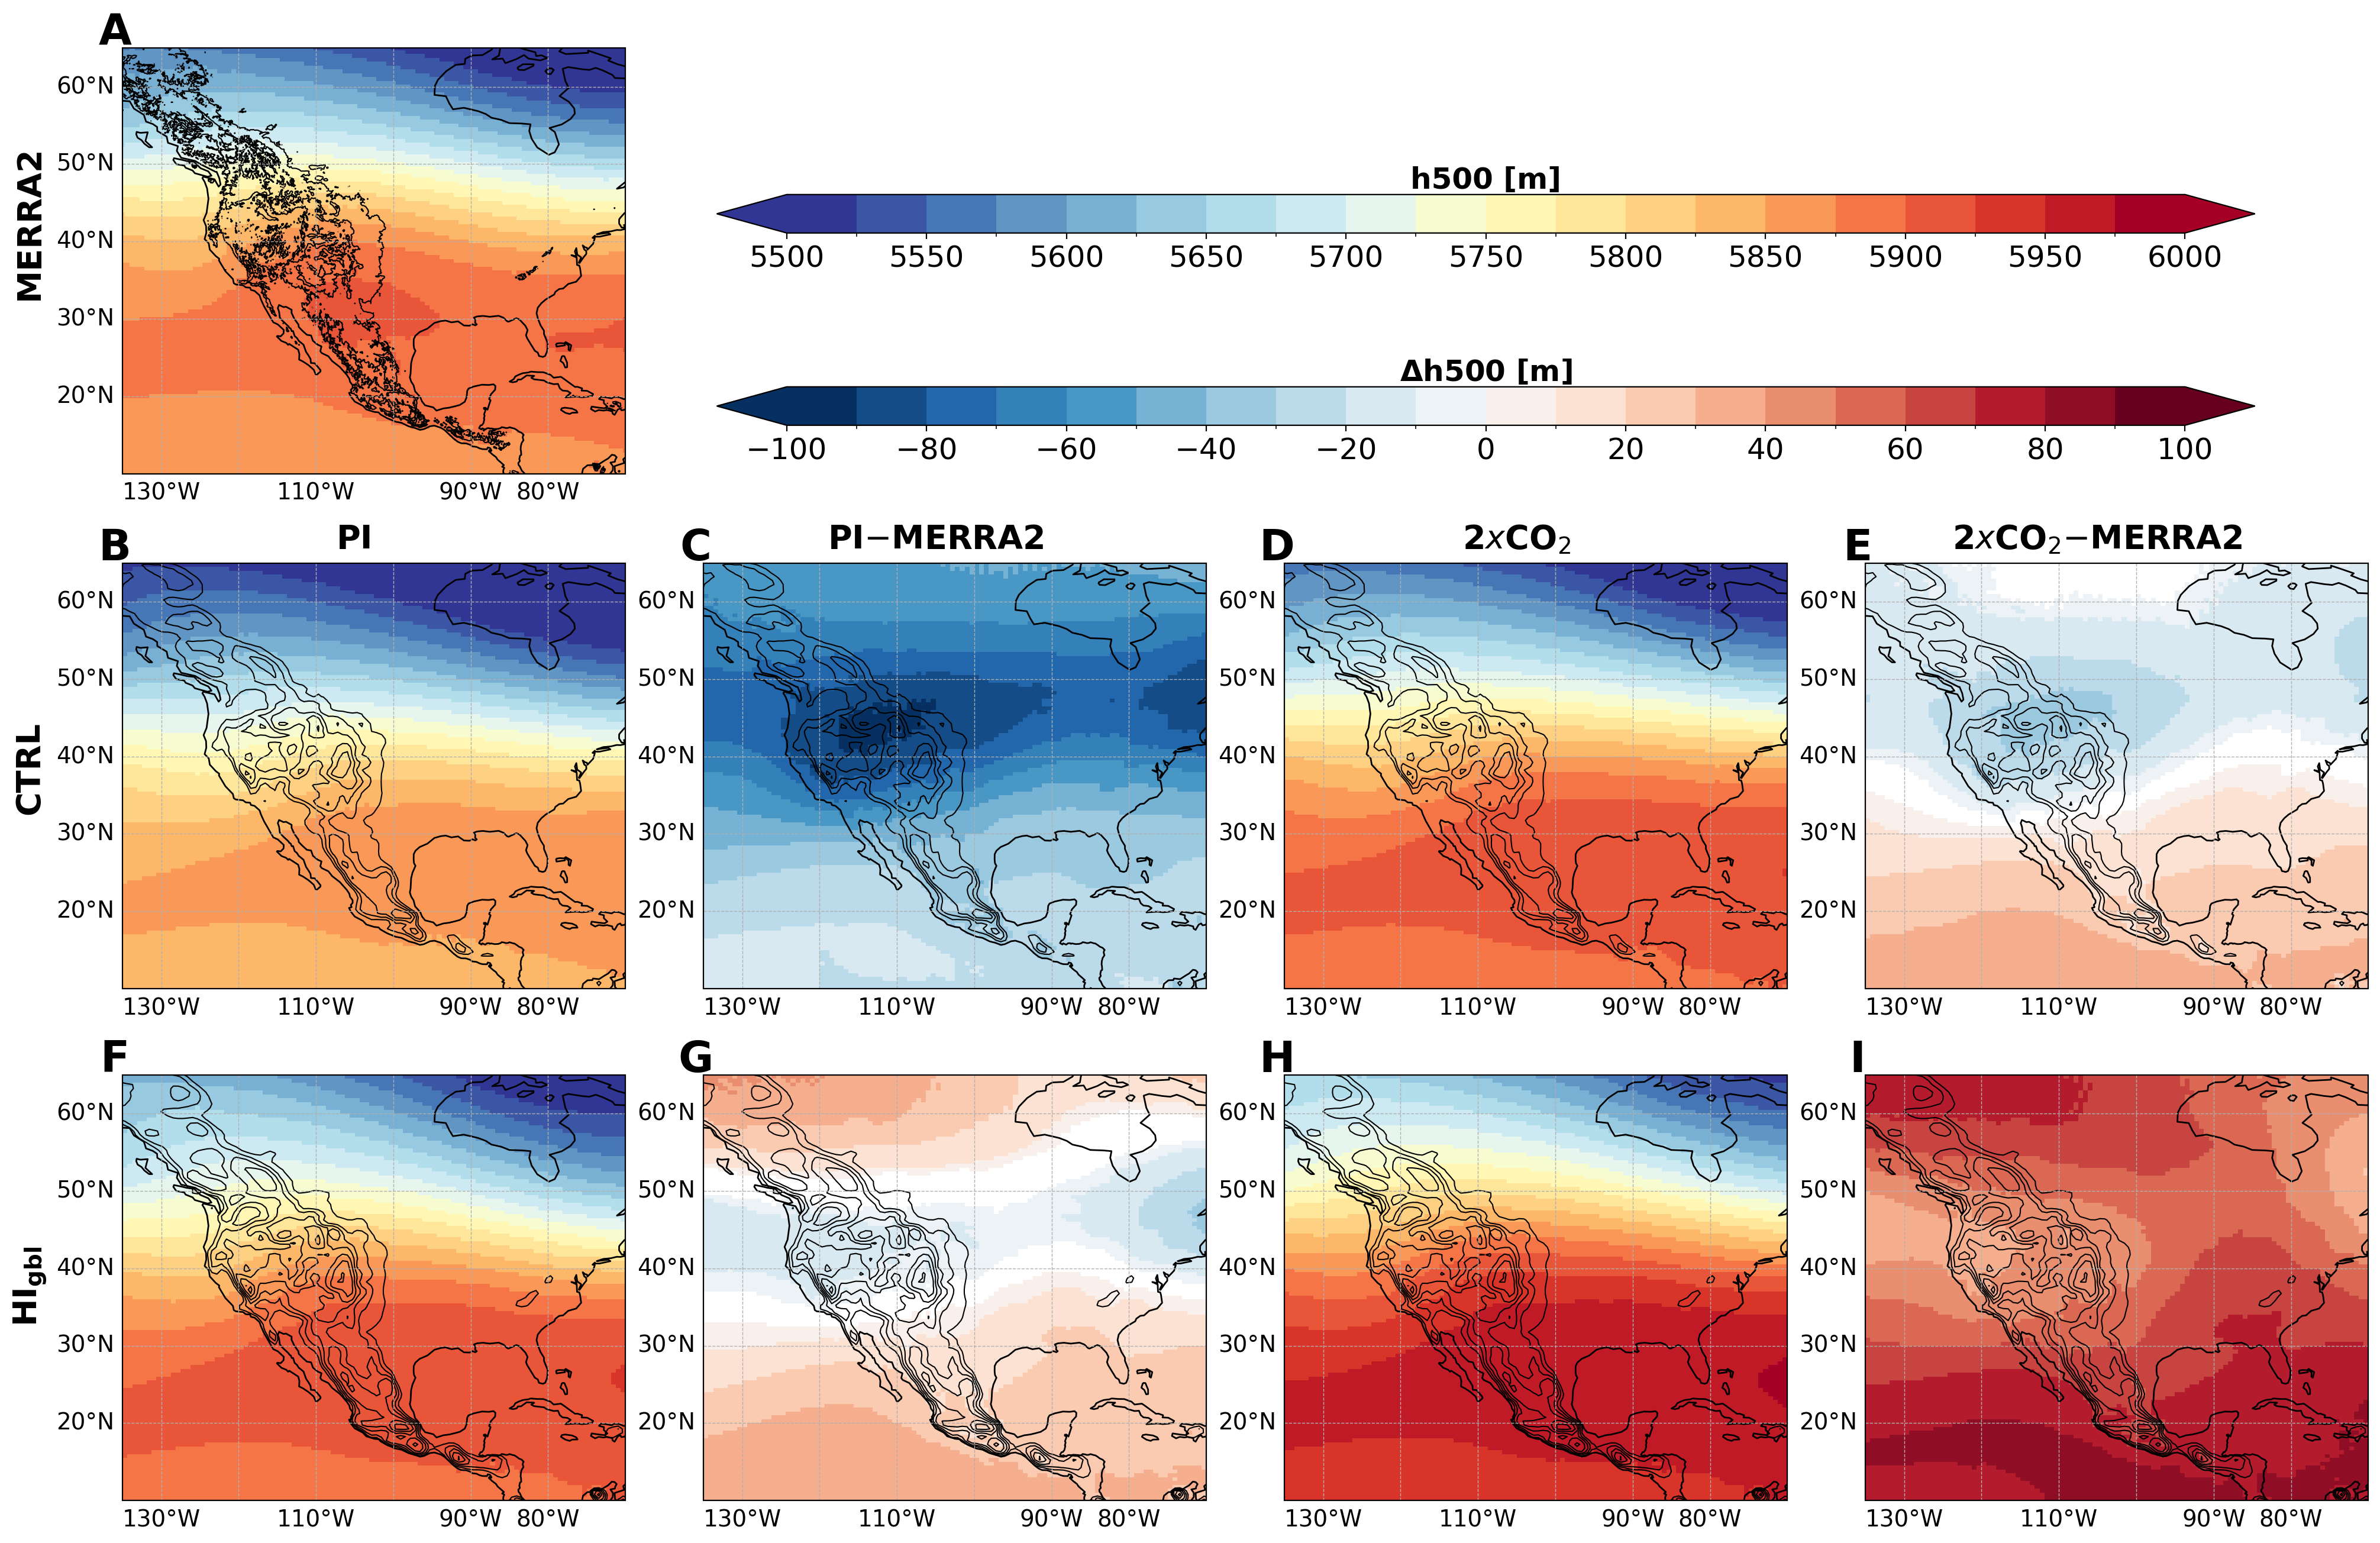

In [13]:
# --- settings --- #
# plot specs
lw=1
text_kw={'color':'k', 'weight':'bold', 'size':20, 'ha':'center', 'va':'bottom'}
text_kw2={'color':'k', 'weight':'bold', 'size':26, 'ha':'center', 'va':'center'}
text_kw3={'color':'k', 'weight':'normal', 'size':14, 'ha':'left', 'va':'center'}
titles=np.array(['MERRA2','CM2.5-FLOR CTRL','CM2.5-FLOR HI-GBL',
                 '','',''])
letters=['A','B','B','B','B','C','D','E','F','G','H','I','J']
tx=-105
ty=66
# var specs
lon = jas_mean['pi']['ctrl']['h500'].lon
lat = jas_mean['pi']['ctrl']['h500'].lat
# topography contours
zlevels=np.linspace(1000,4000,7)
# climo colormap
cmap=cm.RdYlBu_r
vmin=5500
vmax=6000
levels=np.linspace(vmin, vmax, 21)
norm=mpl.colors.BoundaryNorm(levels, cmap.N)
hlevels=np.arange(vmin-50, vmax+50, 25)
# bias colormap
dcmap=cm.RdBu_r
dvmin=-100
dvmax=100
dlevels=np.linspace(dvmin, dvmax, 21)
dnorm=mpl.colors.BoundaryNorm(dlevels, dcmap.N)
# map specs
trans=ccrs.PlateCarree()
proj=ccrs.PlateCarree()
map_bnds=[225,290,10,65]
cols=[0,2]

# --- plot --- #
fig, ax = plt.subplots(nrows=3, ncols=4, figsize=(20,13), layout='constrained', subplot_kw={'projection':proj})

ax[0,0].text(-147,32.5,'MERRA2', rotation=90, **text_kw)
ax[1,0].text(-147,32.5,'CTRL', rotation=90, **text_kw)
ax[2,0].text(-147,32.5,r'HI$\mathbf{_{gbl}}$', rotation=90, **text_kw)
for i,title in enumerate(['PI', 'PI$-$MERRA2', '2$x$CO$_2$', '2$x$CO$_2$$-$MERRA2']):
    ax[1,i].text(tx, ty, title, **text_kw)
    
#=== OBS ===
mlon = jas_mean['obs']['merra2']['h500'].lon
mlat = jas_mean['obs']['merra2']['h500'].lat
ax[0,0].pcolormesh(mlon, mlat, jas_mean['obs']['merra2']['h500'], cmap=cmap, norm=norm, transform=trans)
#ax[0,0].contour(mlon, mlat, jas_mean['obs']['merra2']['h500'], colors='k', levels=hlevels, linewidth=1.5, transform=trans)
ax[0,0].contour(topo['etopo'].lon, topo['etopo'].lat, topo['etopo'], levels=np.linspace(1000,4000,4), linewidths=.75, colors='black', transform=trans)

ax[0,1].set_visible(False)
ax[0,2].set_visible(False)
ax[0,3].set_visible(False)

#=== FLOR ===
run='ctrl'
i=0
for key in ['pi','2xco2']:
    cf=ax[1,i].pcolormesh(lon, lat, jas_mean[key][run]['h500'], cmap=cmap, norm=norm, transform=trans)
    cf2=ax[1,i+1].pcolormesh(lon, lat, obs_diff_mask[key][run]['h500'], cmap=dcmap, norm=dnorm, transform=trans)
    i+=2

run='hitopo'
i=0
for key in ['pi','2xco2']:
    ax[2,i].pcolormesh(lon, lat, jas_mean[key][run]['h500'], cmap=cmap, norm=norm, transform=trans)
    ax[2,i+1].pcolormesh(lon, lat, obs_diff_mask[key][run]['h500'], cmap=dcmap, norm=dnorm, transform=trans)
    i+=2           

for i,run in enumerate(['ctrl','hitopo']):
    for j in [0,1,2,3]:
        ax[i+1,j].contour(lon, lat, topo[run], levels=zlevels, linewidths=.75, colors='black', transform=trans)

# --- formatting --- #
for i, ax in enumerate(ax.flat): 
    # subplot labels
    ax.text(-136, ty+1, letters[i], **text_kw2)
    # map properties
    ax.coastlines(color='k', linewidth=1)
    ax.set_extent(map_bnds, crs=trans)
    gl=ax.gridlines(crs=trans, lw=.5, colors='black', alpha=1.0, linestyle='--', zorder=10, draw_labels=True)
    gl.bottom_labels=True; gl.left_labels=True; gl.top_labels=False; gl.right_labels=False
    gl.xformatter=LONGITUDE_FORMATTER
    gl.yformatter=LATITUDE_FORMATTER
    gl.xlabel_style={'color': 'black', 'weight': 'normal', 'size':14}
    gl.ylabel_style={'color': 'black', 'weight': 'normal', 'size':14}

# --- colorbars --- #
# climo
cax=fig.add_axes([.3, 0.85, 0.65, 0.025])
cbar=fig.colorbar(cf, ticks=np.linspace(5500,6000,11), orientation='horizontal', extend='both', cax=cax) 
cbar.set_label('h500 [m]', labelpad=-65, size=18, fontweight='bold', ha='center')
cbar.ax.tick_params(labelsize=18)

# bias
cax=fig.add_axes([.3, 0.725, 0.65, 0.025])
cbar=fig.colorbar(cf2, ticks=np.linspace(-100,100,11), orientation='horizontal', extend='both', cax=cax) 
cbar.set_label(r'$\mathbf{\Delta}$h500 [m]', labelpad=-65, size=18, fontweight='bold', ha='center')
cbar.ax.tick_params(labelsize=18)

#plt.savefig(f'figs/h500.flor.pi.2xco2.bias.change.pdf', transparent=False, bbox_inches='tight')
#plt.savefig(f'figs/h500.flor.pi.2xco2.bias.change.pdf', transparent=False, bbox_inches='tight')